In [ ]:
# --- Paths (repo-relative; this notebook runs from notebooks/) ---
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
DATA      = PROJECT_ROOT / 'data'
RAW       = DATA / 'raw'          # external source data (read-only)
EXTERNAL  = DATA / 'external'     # frozen third-party / HPC-derived inputs (read-only)
ANNOTATED = DATA / 'annotated'    # tables derived by these notebooks
FIGURES   = PROJECT_ROOT / 'figures'
# The ENSG->UniProt mapping behind TF labels exists only on the AKEY cluster; off-cluster the
# per-gene TF labels it produced are read from data/external/hpc_snapshot/ (see its README).


# Packages

In [ ]:
# Environment: install the pinned dependencies with `pip install -r requirements.txt`
# from the repository root (see README.md). No packages are installed from inside notebooks.


In [ ]:
import sys, os, requests, json, glob, re
import subprocess, math
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from scipy.stats import mannwhitneyu, spearmanr, pearsonr, kruskal, ttest_ind, wilcoxon
import statsmodels.api as sm
import statsmodels.formula.api as smf
from Bio import SeqIO
from Bio.Seq import Seq
from pathlib import Path
from tqdm import tqdm
import pandas as pd
import numpy as np
# loads packages

In [ ]:
from pathlib import Path
import gzip

fpath = Path("../data/raw/uniprot/uniprotkb_allproteins.fasta") # UNIPROT ALL HUMAN PROTEINS, SWISSPROT, CANONICAL + ISOFORMS

with open(fpath, "rt") as fh: # ** use gzip.open instead of open to open compressed file
    total = sum(1 for line in fh if line.startswith(">")) # each header with '>' represents one protein

print(total) # prints total proteins, which is the amount of rows

# Filtering the human proteome 

## **Import FASTA (updated dataset with isoforms)**

original file:  
UP000005640_9606.fasta | [Downloaded on 12/9/2025, files last updated on 10/15/2025](https://ftp.uniprot.org/pub/databases/uniprot/current_release/knowledgebase/reference_proteomes/Eukaryota/UP000005640/UP000005640_9606.fasta)
> Total entries: 20,659  
> Swiss-Prot reviewed entries: 20,329  
> TrEMBL unreviewed entries: 330  
> Isoform accessions (with '-'): 0


**new file:**
uniprotkb_allproteins.fasta | [Downloaded on 6/2/2025](https://www.uniprot.org/uniprotkb/statistics) | [Files published on 1/28/2026](https://www.uniprot.org/uniprotkb?query=*&facets=reviewed%3Atrue%2Cmodel_organism%3A9606)  
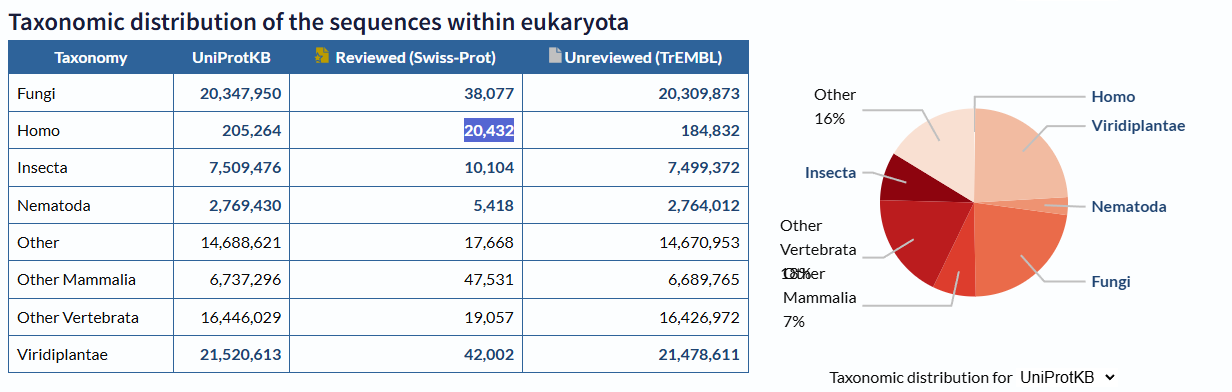
> Total entries: 42,562  
> Swiss-Prot reviewed entries: 42,562  
> TrEMBL unreviewed entries: 0 - no unreviewed entries  
> Isoform accessions (with '-'): 22,131 | **uniprot isoforms are sorted with a dash after entry-id and Isoform in the human name**  
> Canonical accessions: 20431  

In [ ]:
fpath = Path("../data/raw/uniprot/uniprotkb_allproteins.fasta")

pattern = re.compile(r"^(\S+)\|(\S+)\|(\S+)\s+"r"(.*?)\s+OS=(.*?)\s+OX=(\d+)"r"(?:\s+GN=(\S+))?"r"(?:\s+PE=(\d+))?"r"(?:\s+SV=(\d+))?") # new header format for new file (isoforms do not contain PE= and SE= columns).

with open(fpath, "rt") as fh:
    total = sum(1 for line in fh if line.startswith(">"))

data = []
failed_headers = []

with open(fpath, "rt") as fasta_file:
    for seq_record in tqdm(SeqIO.parse(fasta_file, "fasta"), total=total):
        header = seq_record.description
        sequence = str(seq_record.seq)

        match = pattern.match(header)

        if match is None: # check if any headers fail
            failed_headers.append(header)
            continue

        db, unique_id, entry_name, protein_name, organism_name, organism_id, gene_name, protein_existence, sequence_version = match.groups()
        data.append({
            "db": db,"Entry": unique_id,"prot_info": protein_name,
            "gene_name": gene_name if gene_name else "N/A",
            "prot_existence": int(protein_existence) if protein_existence else None,
            "prot_seqVersion": int(sequence_version) if sequence_version else None,
            "Length": len(sequence),"Sequence": sequence,
        })

fasta_df = pd.DataFrame(data)
print(fasta_df.shape[0], "total parsed proteins")

# IMPORTANT: creates two new columns to isolate isoform and base accession identifiers
fasta_df["isoform_accession"] = fasta_df["Entry"] # keeps the isoform accession
fasta_df["base_accession"] = fasta_df["Entry"].str.split("-").str[0] # removes dash, to check if same gene or not 
fasta_df["is_canonical"] = ~fasta_df["Entry"].str.contains("-", regex=False) # checks if canonical or not

## Filter for high confidence proteins

In [ ]:
# filter gene high confidence proteins

print(fasta_df.shape[0], "proteins/isoforms before filtering")
# fasta_df = fasta_df[~ fasta_df.duplicated('gene_name', keep=True)] # removes all duplicated gene names ~ looking at isoforms so -> REMOVE

# fill missing PE's for isoforms using canonical PEs | POSTULATE/ASSUMPTION: Isoforms contain same PE (existence literature level) as canonical.
canonical_pe = (
    fasta_df
    .query("is_canonical")
    .set_index("base_accession")["prot_existence"]
)

fasta_df["base_prot_existence"] = fasta_df["base_accession"].map(canonical_pe)
fasta_df["prot_existence_filled"] = fasta_df["prot_existence"].fillna(fasta_df["base_prot_existence"])

# Filters for isoform-aware project
fasta_df = fasta_df.query('db == "sp"') # protein is SwissProt
fasta_df = fasta_df.query('gene_name != "N/A"') # protein contains known Gene Name
fasta_df = fasta_df.query("Length >= 20") # protein is >= 20 amino acids
fasta_df = fasta_df.query("prot_existence_filled < 5") # proteins aren't uncertain

# Keep only genes/base proteins with >2 protein entries:
# at least 1 canonical + at least 2 alternative isoforms
isoform_counts_filter = (fasta_df.groupby("base_accession")["isoform_accession"].nunique().rename("n_isoforms").reset_index())
base_accessions_gt2_isoforms = (isoform_counts_filter.query("n_isoforms > 2")["base_accession"])
fasta_df = fasta_df.query("base_accession.isin(@base_accessions_gt2_isoforms)").copy()

print("----------")
print(fasta_df.shape[0], "proteins/isoforms after filtering")
print(fasta_df["is_canonical"].sum(), "canonical & unique base entries")
print((~fasta_df["is_canonical"]).sum(), "alternative isoform entries")

In [ ]:
n_total_entries = fasta_df.shape[0] # One row per isoform/protein sequence
n_base_proteins = fasta_df["base_accession"].nunique() # One base accession per canonical protein/gene-level protein record

# Count isoforms per base protein
isoform_counts = (fasta_df.groupby("base_accession")["isoform_accession"].nunique().rename("n_isoforms").reset_index())

# Add gene name for readability
gene_lookup = (fasta_df.groupby("base_accession")["gene_name"].first().reset_index())
isoform_counts = isoform_counts.merge(gene_lookup, on="base_accession", how="left")

# Genes/proteins with more than one isoform entry
with_isoforms = isoform_counts.query("n_isoforms > 1")
without_isoforms = isoform_counts.query("n_isoforms == 1")

## Columns to inherit from canonical/base protein -> isoforms | gene/protein-level annotations. 

In [ ]:
# ============
# below is a list of useful/most annotations taken from the annotations table. depending on depth of research, data filtering, and idmapping on the proteome, certain features may be included/disregarded.
# https://www.uniprot.org/help/return_fields | all annotations were downloaded, can add any based on here in "" depending on needs.
# ============
inherit_cols = [
    "base_accession",                 # Canonical UniProt accession; maps P12345-2/P12345-3 back to P12345
    # ---- identity ----
    "Reviewed",                       # UniProt reviewed statys
    "Entry Name",                     # UniProt entry name, e.g. P53_HUMAN
    "Protein names",                  # Full protein name
    # "Organism (ID)",                  # Taxonomy ID, human = 9606
    "Proteomes",                      # UniProt proteome ID
    # ---- protein literature quality ----
    "Protein existence",              # Protein evidence level; 1 strongest, 5 weakest
    "Protein families",               # UniProt protein family annotation
]

# %% Columns to bring over as canonical-only feature annotations
bring_cols = [
    "base_accession",                 # Canonical UniProt accession
    "Alternative products (isoforms)", # UniProt text describing known isoforms
]

# Add annotations (for transcription factors)

Downloaded from UPKB API -> **all annotations**  

## create master **isoform_df** filtered data
> fasta_df = isoform-specific sequence table  
> annot_raw = raw full UniProt annotation table with all filters  
> annot_core = annot_raw *with* selected gene/base-level annotations  
> **isoform_df = isoform-specific sequences + broad annotations**  

In [ ]:
fpath = "../data/raw/uniprot/uniprotkb_annotated" # Load UniProt annotation table
annot_raw = pd.read_csv(fpath, sep="\t", low_memory=False)

annot_raw = annot_raw.rename(columns={"Entry": "base_accession"}) # Entry = canonical/base accession

# CHECK: only keep columns found in annotations list if modified by user for analysis
inherit_cols = [c for c in inherit_cols if c in annot_raw.columns]
bring_cols = [c for c in bring_cols if c in annot_raw.columns]
    
# %% Build annotation tables

# Broad annotations inherited by all isoforms
annot_core = annot_raw[inherit_cols].copy()
annot_core = annot_core.drop_duplicates(subset="base_accession", keep="first")
# Canonical-only feature annotations
annot_features = annot_raw[bring_cols].copy()
annot_features = annot_features.drop_duplicates(subset="base_accession", keep="first")
# rename so merges only onto exact canonical isoform_accession
annot_features = annot_features.rename(columns={"base_accession": "isoform_accession"})

# %% Merge annotations
# inherited/core annotations -> canonical + alternative isoforms
isoform_df = fasta_df.merge(annot_core,on="base_accession",how="left")
# canonical-only feature annotations only -> canonical rows
isoform_df = isoform_df.merge(annot_features,on="isoform_accession",how="left")
# Formatting: sort canonical first and then isoforms together in csv neatly
isoform_df = isoform_df.sort_values(by=["base_accession", "is_canonical", "isoform_accession"],ascending=[True, False, True]).reset_index(drop=True)

# ----
# %% Checks
print("CHECK: rows lost,", fasta_df.shape[0] - isoform_df.shape[0])
print("canonical entries:", isoform_df["is_canonical"].sum())
print("alternative isoform entries:", (~isoform_df["is_canonical"]).sum())
# Save important tables
outdir = Path("../data/annotated")
outdir.mkdir(parents=True, exist_ok=True)

# annot_core.to_csv(outdir / "annot_core.csv", index=False)
# annot_features.to_csv(outdir / "annot_features.csv", index=False)
isoform_df.to_csv(outdir / "isoform_df.csv", index=False)
fasta_df.to_csv(outdir / "fasta_df.csv", index=False)

## add additional ID mappings (ENSG, RefSeq, etc)

In [ ]:
# Add additional ID mappings
# HPC-only input: UniProt idmapping for the reference proteome. Its outputs are not used by any
# notebook or pipeline stage (TF labels below use a separate ENSG->UniProt table). Skipped off-cluster.
fpath = "/scratch/gpfs/AKEY/ssong/tf_idr_paper/data/proteome_annot/uniprot/UP000005640_9606.idmapping" # contains uniprot accessions and other database IDs, translational table
if Path(fpath).exists():

    idmapping = pd.read_csv(fpath,sep="\t",header=None,
        names=["base_accession", "database", "id"]) # base_accession = uniprot acession like P12345, database = what database external ID came from, ID = external database ID

    # filter id mappings for only filtered proteins
    base_accessions = isoform_df["base_accession"].unique()
    idmapping = idmapping.query("base_accession.isin(@base_accessions)").copy()

    # Save full mapping table_
    outpath = "../data/annotated/idmapping_cohort.csv"  # never write into data/raw
    idmapping.to_csv(outpath)

    # extract ensembl gene IDs (ensg) column
    ensg_to_upkb = (idmapping[idmapping["id"].str.startswith("ENSG", na=False)].copy())
    ensg_to_upkb["ENSG"] = ensg_to_upkb["id"].str.split(";", expand=True)[0] # clean any extra semi-colons in data
    ensg_to_upkb = ( # creates table with just two columns: ENSG and base_accession (uniprot)
        ensg_to_upkb[["ENSG", "base_accession"]].drop_duplicates().reset_index(drop=True))

    ensg_to_upkb.head()
    outpath = "../data/annotated/ensg_to_upkb_cohort.csv"  # never write into data/raw
    ensg_to_upkb.to_csv(outpath)

    print("ENSG mappings:", ensg_to_upkb.shape[0])
    print("Unique ENSG IDs:", ensg_to_upkb["ENSG"].nunique())
    print("Unique UniProt base accessions:", ensg_to_upkb["base_accession"].nunique())
else:
    print('HPC idmapping not available; skipping (outputs unused downstream).')


# Annotation of Transcription Factors on isoform_df

In [ ]:
# %% Annotate transcription factors
HPC_TF_CSV = "/scratch/gpfs/AKEY/ssong/tf_idr_paper/data/proteome_annot/tfs/DatabaseExtract_v_1.01.csv"
HPC_ENSG_TO_UPKB = "/scratch/gpfs/AKEY/ssong/tf_idr_paper/data/idmapping/ensg_to_upkb.parquet"
TF_SNAPSHOT = EXTERNAL / "hpc_snapshot" / "tf_labels_from_hpc_mapping.csv"

if Path(HPC_TF_CSV).exists() and Path(HPC_ENSG_TO_UPKB).exists():
    # Original derivation (AKEY cluster)
    fpath = HPC_TF_CSV  # curated TF database
    tfdb_df = pd.read_csv(fpath, index_col=0)

    # Filter for true TFs from database -- same as Susie
    tfdb_df = tfdb_df.query('`Is TF?` == "Yes"').copy()
    print(tfdb_df.shape[0], "TFs before mapping")

    # Load ENSG -> UniProt accession mapping -- same as Susie
    fpath = HPC_ENSG_TO_UPKB
    ensg_to_upkb = pd.read_parquet(fpath, engine="fastparquet")

    # Map Ensembl gene ID -> UniProt accession -- same as Susie
    ensg_to_upkb_dict = dict(zip(ensg_to_upkb["ENSG"], ensg_to_upkb["upkb_accession"]))
    tfdb_df["upkb_accession"] = tfdb_df["Ensembl ID"].map(ensg_to_upkb_dict)

    # Remove TFs that do not map
    tfdb_df = tfdb_df.dropna(subset=["upkb_accession"]).copy()

    # Create base_accession so your downstream code still works
    tfdb_df["base_accession"] = (tfdb_df["upkb_accession"].astype(str).str.split("-").str[0])

    # Keep one row per UniProt base accession
    tfdb_df = tfdb_df.drop_duplicates("base_accession").copy()
    print(tfdb_df.shape[0], "TFs after mapping/filtering")
else:
    # Off-cluster: per-gene result of exactly the derivation above, frozen from the cluster run.
    # No local ENSG->UniProt table reproduces it (see data/external/hpc_snapshot/README.md).
    tfdb_df = pd.read_csv(TF_SNAPSHOT)
    tfdb_df["Is TF?"] = "Yes"
    print(tfdb_df.shape[0], "TFs after mapping/filtering (HPC snapshot)")


In [ ]:
tf_cols_to_drop = [ # tf columns to add**** - change if further analysis
    "is_tf","DBD","tf_family","tf_group"]
isoform_df = isoform_df.drop( # drop previous if above modified
    columns=[c for c in tf_cols_to_drop if c in isoform_df.columns])
# Create TF annotation table from curated TF database**
tf_labels = (tfdb_df[["base_accession", "Is TF?", "DBD"]]
    .rename(columns={"Is TF?": "is_tf"}).drop_duplicates("base_accession").copy())

tf_labels["is_tf"] = True
tf_labels["tf_family"] = tf_labels["DBD"].fillna("Unknown")
# Merge TF labels onto every isoform
isoform_df = isoform_df.merge(tf_labels,on="base_accession",how="left")
# Proteins not in curated TF database are non-TFs
isoform_df["is_tf"] = isoform_df["is_tf"].fillna(False)
isoform_df["tf_family"] = isoform_df["tf_family"].fillna("Non-TF")
isoform_df["DBD"] = isoform_df["DBD"].fillna("Non-TF")
# Broad TF vs non-TF grouping
isoform_df["tf_group"] = np.where(isoform_df["is_tf"],"TF","Non-TF")

# Create TF-only Dataset from Isoforms
**tf_ds** dataset is isoforms

In [ ]:
# %% Create TF-only dataset
tf_ds = isoform_df.query("is_tf").copy()
# FORMAT: sort canonical first, then isoforms
tf_ds = tf_ds.sort_values(by=["base_accession", "is_canonical", "isoform_accession"],ascending=[True, False, True]).reset_index(drop=True)

In [ ]:
# Summary
print("Total Proteins (canonical + isoforms):", isoform_df.shape[0])
print("Unique/canonical proteins:", isoform_df["base_accession"].nunique())
print("TF proteins:", isoform_df.query("is_tf")["base_accession"].nunique())
print("TF isoforms:", isoform_df["is_tf"].sum())
print("Non-TF isoforms:", (~isoform_df["is_tf"].astype(bool)).sum())
print("Total TFs (canonical + isoforms):", tf_ds.shape[0])
print("Canonical TFs:", tf_ds["is_canonical"].sum())
print("Alternative TF isoforms:", (~tf_ds["is_canonical"]).sum())

print("\nTop TF families:")
print(isoform_df.loc[isoform_df["is_tf"], "tf_family"].value_counts().head(10))

# Prediction of Intrinsically Disordered Regions

Results from MetaPredict v3.1 [Colab Notebook](https://colab.research.google.com/github/holehouse-lab/ALBATROSS-colab/blob/main/idrome_constructor/idrome_constructor.ipynb) **on the New Dataset**  

> idrome_df: raw IDRome output after filtering    
> idr_df: cleaned version to match workflow  
> idr_summary: group idrs by their protein isoforms  
> isoform_df: summary of all isoforms idrs  

In [ ]:
# %% Add IDRome / IDR calls to isoform_df
# load IDRome data
fpath = "../data/raw/metapredict/IDRome_AllSwissProtHumansProIsos.csv"
idrome_df = pd.read_csv(fpath, sep=", ", engine="python")
# Keep only IDR calls for isoforms/proteins present in the filtered isoform_df
print(idrome_df.shape[0], "IDR segments before filtering")
valid_isoforms = isoform_df["isoform_accession"].unique()
idrome_df = idrome_df.query("UniProtID.isin(@valid_isoforms)").copy() # exact isoform ids
# Filter out short IDRs
idrome_df = idrome_df.query("`IDR len` >= 20").copy() 
print(idrome_df.shape[0], "IDR segments after filtering")
print(idrome_df["UniProtID"].nunique(), "unique isoforms with at least one IDR")
# renaming
idr_df = idrome_df.rename(
    columns={
        "UniProtID": "isoform_accession", # Rename IDRome columns for isoforms "
        "IDR len": "idr_aaLen",
        "IDR start": "idr_start_aa",
        "IDR end": "idr_end_aa",
        "Rg (A)": "Rg_A",
        "Re (A)": "Re_A",
    }
).copy()
# add base_accession column to group by gene/protein
idr_df.insert(
    1,  # column position: right after isoform_accession
    "base_accession",
    idr_df["isoform_accession"].str.split("-").str[0]
)
# ---
# Aggregate IDR calls per isoform***
idr_summary = (
    idr_df
    .groupby("isoform_accession")
    .agg(
        idr_aaLen=("idr_aaLen", "sum"),              # total disordered AA across all IDRs in this isoform
        n_idr_segments=("idr_aaLen", "size"),        # number of IDR segments in this isoform
        max_idr_len=("idr_aaLen", "max"),            # longest IDR in this isoform
        mean_idr_len=("idr_aaLen", "mean"),          # average IDR length
        mean_Rg_A=("Rg_A", "mean"),                  # average radius of gyration across IDRs
        mean_Re_A=("Re_A", "mean"),                  # average end-to-end distance across IDRs
        mean_asphericity=("asphericity", "mean"),    # average IDR shape
        mean_scaling_e=("scaling_exponent", "mean"),        # average polymer scaling exponent
        mean_prefactor=("prefactor", "mean"),        # average scaling prefactor
        mean_FCR=("FCR", "mean"),                    # average fraction charged residues
        mean_NCPR=("NCPR", "mean"),                  # average net charge per residue
        mean_kappa=("kappa", "mean"),                # average charge segregation
        mean_fract_neg=("fract_negative", "mean"),        # average negative residue fraction
        mean_fract_pos=("fract_positive", "mean"),        # average positive residue fraction
        mean_fract_aro=("fract_aro", "mean"),        # average aromatic residue fraction
        mean_fract_pro=("fract_pro", "mean"),        # average proline fraction
        mean_fract_pol=("fract_polar", "mean"),        # average polar residue fraction
        mean_fract_ali=("fract_ali", "mean"),        # average aliphatic residue fraction
    ).reset_index())

# ----
# Merge aggregated IDR summary onto isoform_df | # drop old dataset + merge new one if rerunning analysis
idr_cols_to_drop = ["idr_aaLen","n_idr_segments","max_idr_len","mean_idr_len","mean_Rg_A","mean_Re_A","mean_asphericity","mean_scaling_e",
    "mean_prefactor","mean_FCR", "mean_NCPR","mean_kappa","mean_fract_neg","mean_fract_pos","mean_fract_aro","mean_fract_pro","mean_fract_pol",
    "mean_fract_ali","pct_idr"]

isoform_df = isoform_df.drop( # drop previous columns (if rerunning)
    columns=[c for c in idr_cols_to_drop if c in isoform_df.columns])
isoform_df = isoform_df.merge( # re-adding these columns w/ new values
    idr_summary,on="isoform_accession",how="left")

# Isoforms w/ no IDRs gets filled in with 0 for IDR length/count
isoform_df["idr_aaLen"] = isoform_df["idr_aaLen"].fillna(0)
isoform_df["n_idr_segments"] = isoform_df["n_idr_segments"].fillna(0)
# Percent IDR for each isoform
isoform_df["pct_idr"] = isoform_df["idr_aaLen"] / isoform_df["Length"] * 100

# Save the per-segment IDR table (>=20 aa, cohort isoforms) and the isoform master table
idr_df.to_csv("../data/annotated/idr_df.csv", index=False)
isoform_df.to_csv("../data/annotated/IDRisoforms_df.csv", index=False)


## **also filter for a TF-specific IDR isoform dataset**

In [ ]:
# %% TF-only isoform dataset

# Keep only transcription factor proteins and all their isoforms
tf_isoform_df = isoform_df.query("is_tf").copy()
# Sort canonical first, then alternative isoforms
tf_isoform_df = tf_isoform_df.sort_values(
    by=["base_accession", "is_canonical", "isoform_accession"],
    ascending=[True, False, True]
).reset_index(drop=True)

# Save TF-only isoform dataset
outpath = "../data/annotated/TranscriptionIsoforms_df.csv"
tf_isoform_df.to_csv(outpath, index=False)